In [29]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import datasets
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [30]:
(X_train, y_train), (X_test, y_test) = datasets.boston_housing.load_data()

# Display the shape of the datasets
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (404, 13)
y_train shape: (404,)
X_test shape: (102, 13)
y_test shape: (102,)


In [31]:
model_single = Sequential([
    Input((13,)),
    Dense(1, input_dim=X_train.shape[1])
    ])
model_single.compile(optimizer='sgd', loss='msle', metrics=['accuracy','msle'])

history_single = model_single.fit(X_train, y_train, epochs=10)

Epoch 1/10
13/13 [==============================] - 0s 2ms/step - loss: 9.6347 - accuracy: 0.0000e+00 - msle: 9.6347
Epoch 2/10
13/13 [==============================] - 0s 2ms/step - loss: 9.6347 - accuracy: 0.0000e+00 - msle: 9.6347
Epoch 3/10
13/13 [==============================] - 0s 2ms/step - loss: 9.6347 - accuracy: 0.0000e+00 - msle: 9.6347
Epoch 4/10
13/13 [==============================] - 0s 2ms/step - loss: 9.6347 - accuracy: 0.0000e+00 - msle: 9.6347
Epoch 5/10
13/13 [==============================] - 0s 2ms/step - loss: 9.6347 - accuracy: 0.0000e+00 - msle: 9.6347
Epoch 6/10
13/13 [==============================] - 0s 2ms/step - loss: 9.6347 - accuracy: 0.0000e+00 - msle: 9.6347
Epoch 7/10
13/13 [==============================] - 0s 2ms/step - loss: 9.6347 - accuracy: 0.0000e+00 - msle: 9.6347
Epoch 8/10
13/13 [==============================] - 0s 2ms/step - loss: 9.6347 - accuracy: 0.0000e+00 - msle: 9.6347
Epoch 9/10
13/13 [==============================] - 0s 2ms/step 

KeyError: 'val_loss'

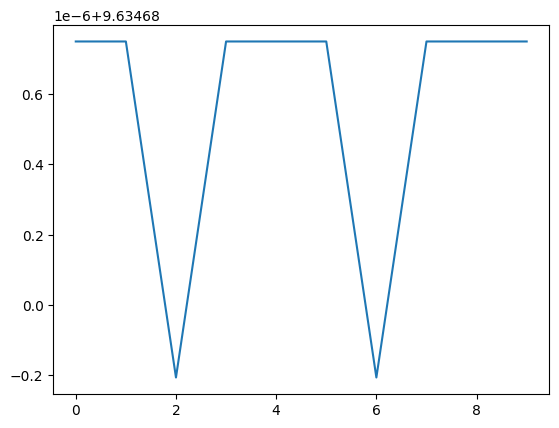

In [32]:
plt.plot(history_single.history['loss'], label='Training Loss')
plt.plot(history_single.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss (Single Neuron)')
plt.legend()
plt.show()

In [34]:
# Load the dataset
from tensorflow.keras.datasets import mnist
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

# Load the Breast Cancer dataset (Binary Classification)
data = load_breast_cancer()
X = data.data
y = data.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build the model (3 Dense Layers)
model_binary = Sequential()
model_binary.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))  # First hidden layer
model_binary.add(Dense(32, activation='relu'))  # Second hidden layer
model_binary.add(Dense(1, activation='sigmoid'))  # Output layer (Binary classification)
model_binary.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Display the model summary
model_binary.summary()

# Train the model
history_binary = model_binary.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=1)



Model: "sequential_15"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_19 (Dense)            (None, 64)                1984      
                                                                 
 dense_20 (Dense)            (None, 32)                2080      
                                                                 
 dense_21 (Dense)            (None, 1)                 33        
                                                                 
Total params: 4,097
Trainable params: 4,097
Non-trainable params: 0
_________________________________________________________________
Epoch 1/100
12/12 [==============================] - 1s 22ms/step - loss: 0.5537 - accuracy: 0.6731 - val_loss: 0.4206 - val_accuracy: 0.8901
Epoch 2/100
12/12 [==============================] - 0s 6ms/step - loss: 0.3280 - accuracy: 0.9341 - val_loss: 0.2667 - val_accuracy: 0.9341
Epoch 3/100
12/12 [=============

In [40]:
# Evaluate the model
loss_binary, accuracy_binary = model_binary.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss (Binary Classification): {loss_binary}")
print(f"Test Accuracy (Binary Classification): {accuracy_binary}")

# Generate classification report
y_pred = (model_binary.predict(X_test) > 0.5).astype(int)
print("Classification Report:")
print(classification_report(y_test, y_pred))

Test Loss (Binary Classification): 0.12509417533874512
Test Accuracy (Binary Classification): 0.9736841917037964
4/4 [==============================] - 0s 1ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [41]:
# Load the Iris dataset
from sklearn.datasets import load_iris
from tensorflow.keras.utils import to_categorical

# Load the dataset
data = load_iris()
X = data.data
y = to_categorical(data.target)  # One-hot encode the target variable

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build the model (3 Dense Layers)
model_multi = Sequential()
model_multi.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))  # First hidden layer
model_multi.add(Dense(32, activation='relu'))  # Second hidden layer
model_multi.add(Dense(3, activation='softmax'))  # Output layer (Multiclass classification)
model_multi.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Display the model summary
model_multi.summary()

# Train the model
history_multi = model_multi.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=1)


Model: "sequential_16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_22 (Dense)            (None, 64)                320       
                                                                 
 dense_23 (Dense)            (None, 32)                2080      
                                                                 
 dense_24 (Dense)            (None, 3)                 99        
                                                                 
Total params: 2,499
Trainable params: 2,499
Non-trainable params: 0
_________________________________________________________________
Epoch 1/100
3/3 [==============================] - 1s 113ms/step - loss: 1.1274 - accuracy: 0.2812 - val_loss: 0.9941 - val_accuracy: 0.5000
Epoch 2/100
3/3 [==============================] - 0s 28ms/step - loss: 1.0765 - accuracy: 0.2917 - val_loss: 0.9417 - val_accuracy: 0.5417
Epoch 3/100
3/3 [=================

In [42]:
# Evaluate the model
loss_multi, accuracy_multi = model_multi.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss (Multiclass Classification): {loss_multi}")
print(f"Test Accuracy (Multiclass Classification): {accuracy_multi}")

# Generate classification report
y_pred = model_multi.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)
print("Classification Report:")
print(classification_report(y_test_classes, y_pred_classes))

Test Loss (Multiclass Classification): 0.051738519221544266
Test Accuracy (Multiclass Classification): 1.0
1/1 [==============================] - 0s 54ms/step
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

